## Loading KDEF dataset

This notebook has the necessary code to load and split your KDEF dataset. The training and test splits are already predefined.

In [ ]:
EMOTIONS = {
    "AF": "afraid",
    "AN": "angry",
    "DI": "disgust",
    "HA": "happy",
    "NE": "neutral",
    "SA": "sad",
    "SU": "surprise",
    
}

POSES = {
    "FL": "full_left",
    "HL": "half_left",
    "S":  "straight",
    "HR": "half_right",
    "FR": "full_right",
}


In [9]:
from pathlib import Path
import pandas as pd
records = []


ROOT = Path("data/KDEF_and_AKDEF/KDEF/")

for img_path in ROOT.rglob("*.JPG"):
    stem = img_path.stem
    acquisition = stem[0]   # A or B
    subject = stem[1:4]     # F01, M12, ...
    found = False

    for emotion_code in EMOTIONS:

        if stem[4:].startswith(emotion_code):

            pose_code = stem[4+len(emotion_code):]

            if pose_code not in POSES:
                continue

            records.append({
                "path": str(img_path),
                "acquisition": acquisition,
                "subject": subject,
                "emotion": EMOTIONS[emotion_code],
                "pose": POSES[pose_code],
            })


            found = True
            break

    if not found:
        print("Skipping:", stem)


Skipping: AF31V
Skipping: AM31H


In [10]:
df = pd.DataFrame(records)

print(df["emotion"].value_counts())
print()
print(df["subject"].nunique())
print(sorted(df.emotion.unique()))
print(df.pose.value_counts())


emotion
afraid      700
angry       700
disgust     700
happy       700
neutral     700
sad         699
surprise    699
Name: count, dtype: int64

70
['afraid', 'angry', 'disgust', 'happy', 'neutral', 'sad', 'surprise']
pose
full_left     980
full_right    980
straight      980
half_left     979
half_right    979
Name: count, dtype: int64


In [11]:
print(df)

                                            path acquisition subject  \
0     data\KDEF_and_AKDEF\KDEF\AF01\AF01AFFL.JPG           A     F01   
1     data\KDEF_and_AKDEF\KDEF\AF01\AF01AFFR.JPG           A     F01   
2     data\KDEF_and_AKDEF\KDEF\AF01\AF01AFHL.JPG           A     F01   
3     data\KDEF_and_AKDEF\KDEF\AF01\AF01AFHR.JPG           A     F01   
4      data\KDEF_and_AKDEF\KDEF\AF01\AF01AFS.JPG           A     F01   
...                                          ...         ...     ...   
4893  data\KDEF_and_AKDEF\KDEF\BM35\BM35SUFL.JPG           B     M35   
4894  data\KDEF_and_AKDEF\KDEF\BM35\BM35SUFR.JPG           B     M35   
4895  data\KDEF_and_AKDEF\KDEF\BM35\BM35SUHL.JPG           B     M35   
4896  data\KDEF_and_AKDEF\KDEF\BM35\BM35SUHR.JPG           B     M35   
4897   data\KDEF_and_AKDEF\KDEF\BM35\BM35SUS.JPG           B     M35   

       emotion        pose  
0       afraid   full_left  
1       afraid  full_right  
2       afraid   half_left  
3       afraid  hal

In [ ]:
"""
#This code is only used for setting up the split. Output file given to the students
#no longer needed afterwards

from sklearn.model_selection import train_test_split

subjects = df["subject"].unique()

train_subjects, test_subjects = train_test_split(
    subjects,
    test_size=0.2,
    random_state=42,
)

train_df = df[df["subject"].isin(train_subjects)]
test_df = df[df["subject"].isin(test_subjects)]


import pickle

split_data = {
    "train_subjects": train_subjects,
    "test_subjects": test_subjects,
}

with open("auxFiles/kdef_subject_split.pkl", "wb") as f:
    pickle.dump(split_data, f)
"""


In [19]:
import pickle

with open("auxFiles/kdef_subject_split.pkl", "rb") as f:
    split_data = pickle.load(f)

train_subjects = split_data["train_subjects"]
test_subjects = split_data["test_subjects"]

print(f"Train subjects: {len(train_subjects)}")
print(f"Test subjects : {len(test_subjects)}")


# Splitting the datasets between front facing images and for the train/test datasets
train_df = df[
    (df["subject"].isin(train_subjects))
    & (df["pose"] == "straight")
]

test_df = df[
    (df["subject"].isin(test_subjects))
    & (df["pose"] == "straight")
]

Train subjects: 56
Test subjects : 14


In [20]:
print("Train images:", len(train_df))
print("Test images :", len(test_df))

Train images: 784
Test images : 196


Subject: F29


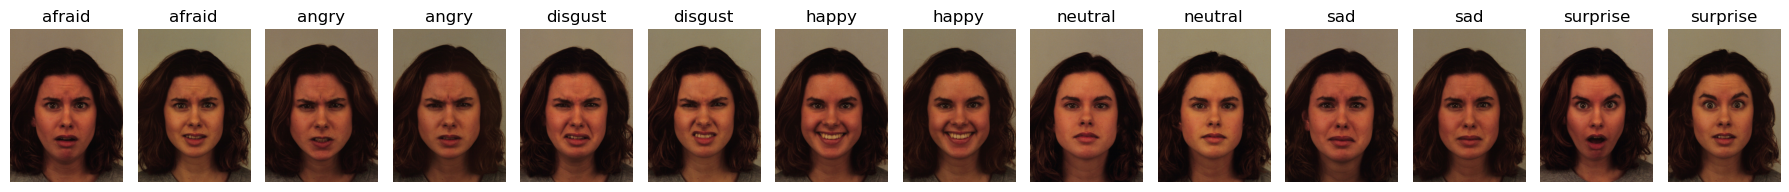

Subject: M11


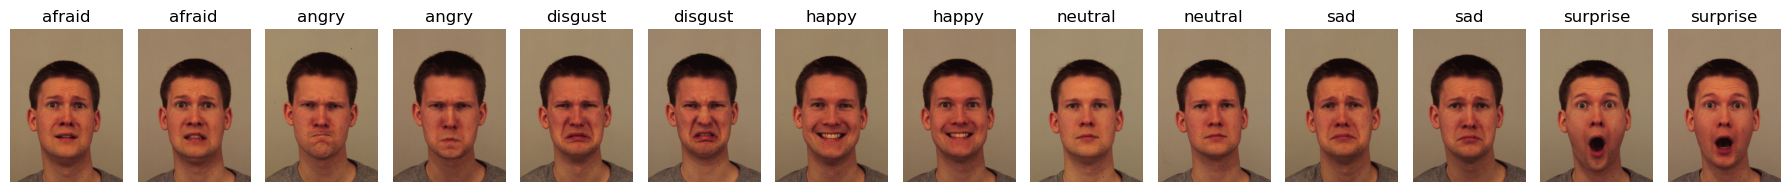

In [21]:
from src.utils_display import show_random_subject_emotions
show_random_subject_emotions(train_df)
show_random_subject_emotions(test_df)

In [ ]:
from src.preprocess import preprocess_kdef_image


img = preprocess_kdef_image(
train_df.iloc[0]["path"]
)

import matplotlib.pyplot as plt

def show_preprocessing(image_path):
    processed = preprocess_kdef_image(image_path)

    plt.figure(figsize=(4,4))
    plt.imshow(processed, cmap="gray")
    plt.axis("off")
    plt.show()

show_preprocessing(
    test_df.iloc[56]["path"]
)

The next part of the code iterates over all the images in the dataset and stores them in np arrays for easy processing

In [ ]:
import numpy as np

X_train = []
y_train = []

for _, row in train_df.iterrows():

    try:
        img = preprocess_kdef_image(
            row["path"]
        )

        X_train.append(img)
        y_train.append(row["emotion"])

    except Exception as e:
        print(e)



X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = []
y_test = []

for _, row in test_df.iterrows():

    try:
        img = preprocess_kdef_image(
            row["path"]
        )

        X_test.append(img)
        y_test.append(row["emotion"])

    except Exception as e:
        print(e)

X_test = np.array(X_test)
y_test = np.array(y_test)


#Storing the preprocessed KDEF dataset


import pickle

data = {
    "X_train": X_train,
    "y_train": y_train,
    "X_test": X_test,
    "y_test": y_test,
}

with open("data/kdef_preprocessed.pkl", "wb") as f:
    pickle.dump(data, f)

print("Saved.")

Now let's see a few of our preprocessed images. Note that both sessions A and B now are stored. The data array contains first all the A session images, and afterwards all the B session images

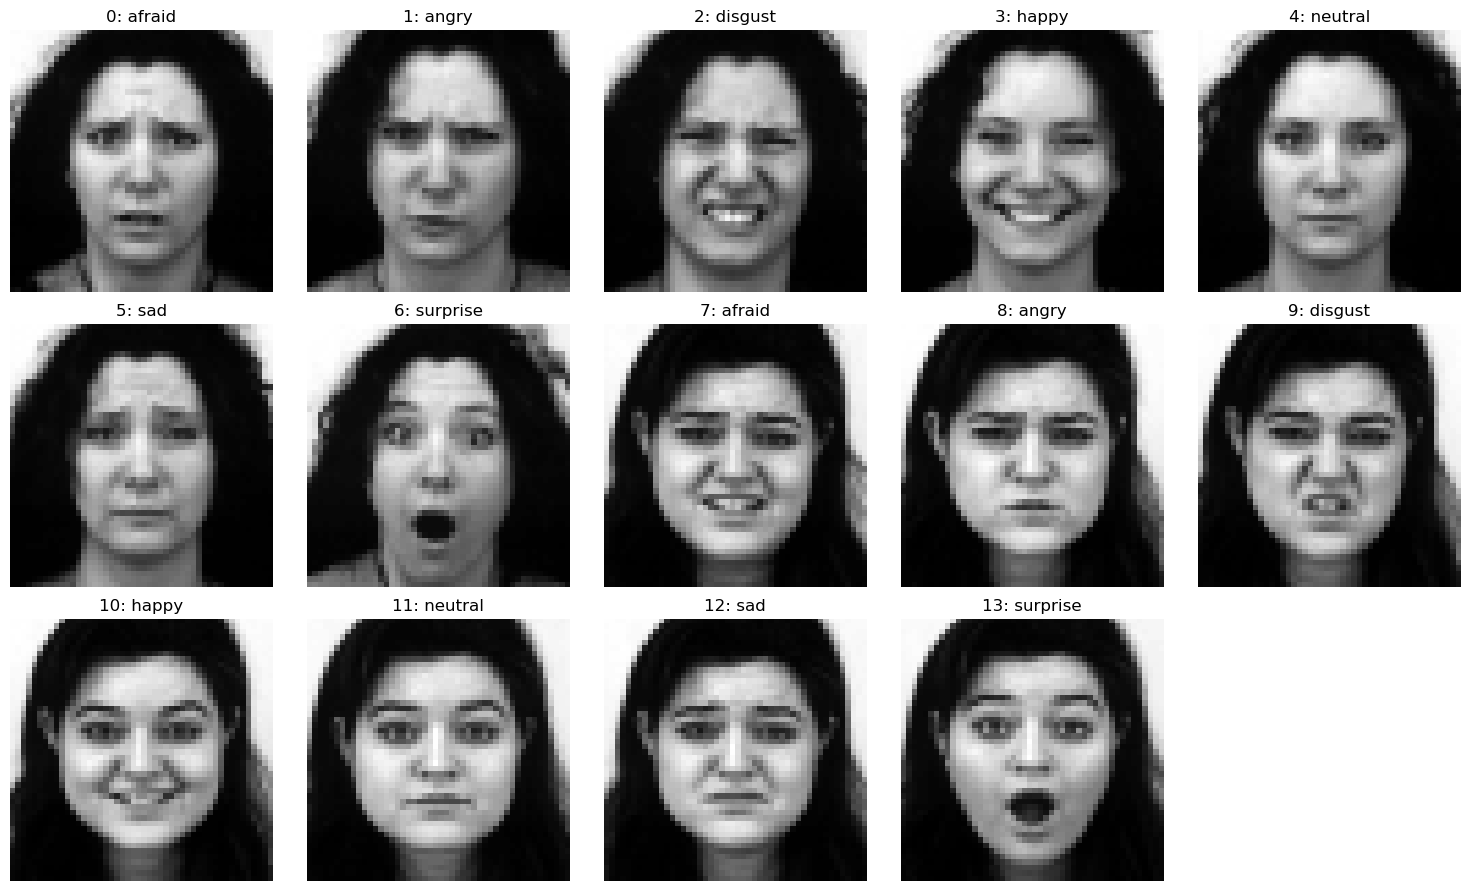

In [ ]:
import matplotlib.pyplot as plt
import math


def show_samples(X, y, start_idx, end_idx):
    """
    Display images from start_idx to end_idx (exclusive)
    together with their emotion labels.
    """

    n = end_idx - start_idx
    cols = 5
    rows = math.ceil(n / cols)

    plt.figure(figsize=(3 * cols, 3 * rows))

    for i, idx in enumerate(range(start_idx, end_idx)):
        plt.subplot(rows, cols, i + 1)

        img = X[idx]

        # grayscale or RGB
        if img.ndim == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)

        plt.title(f"{idx}: {y[idx]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# This is an example of the images of the session A
show_samples(X_train, y_train, start_idx=0, end_idx=14)

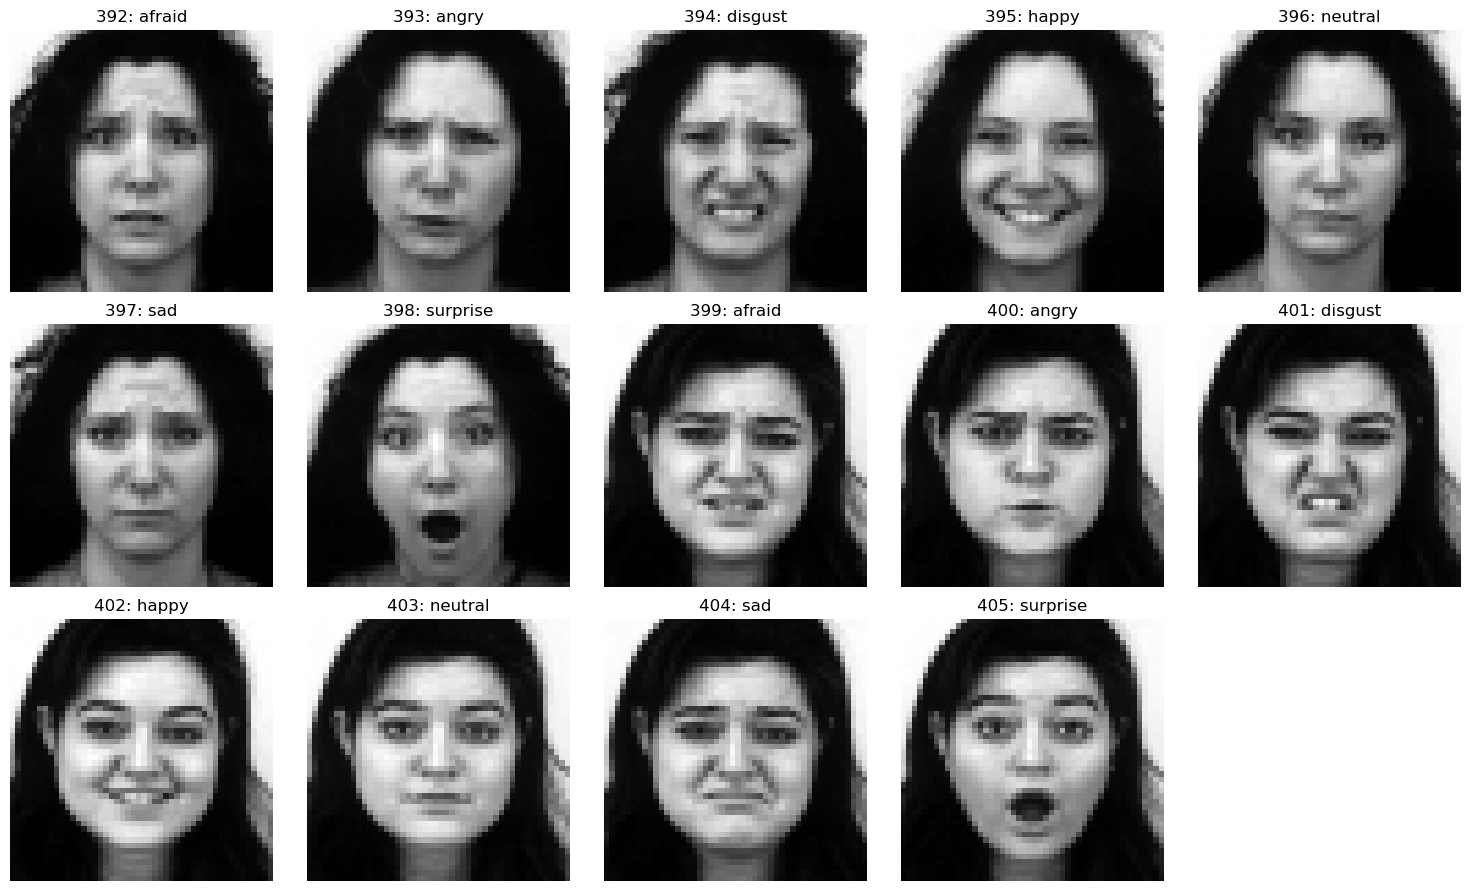

In [ ]:
# This is an example of the images of the session B
show_samples(X_train, y_train, start_idx=392, end_idx=406)